# Part 1: Dogs vs Cats Under Tile Permutations
This notebook trains three image-classification architecture families on Dogs vs Cats.
It evaluates how fixed tile-wise permutations affect validation accuracy.
Results are aggregated by tile count and plotted as accuracy vs number of tiles.


## Setup

### Global / External Imports
Import third-party libraries used only for notebook orchestration and display.


most basic imports

In [1]:
import sys, os
from pathlib import Path
import socket

### Local Imports
Import project modules. Part 1 orchestration lives in this notebook; reusable training, preprocessing, and evaluation helpers stay in `src`.


prep for local imports

In [2]:
def get_project_root() -> str:
    project_root = '/Users/royrubin/Documents/GitHub/MLDS_Final_Project'

    if socket.gethostname() != 'MACs-MacBook-Pro.local':
        try:
            from google.colab import drive  # type: ignore # this import is only available in Colab, so if it succeeds we're in Colab
            # mount drive
            drive.mount('/content/drive')
            project_root = '/content/drive/MyDrive/MLDS_Final_Project'
        except Exception as e:
            raise RuntimeError(f"Error mounting Google Drive: {e}")

    return project_root

# Add project root to sys.path so we can import modules from src
REPO_PATH = get_project_root()
if str(REPO_PATH) not in sys.path:
    sys.path.insert(0, str(REPO_PATH))

print(f"Project root: {REPO_PATH}")

Project root: /Users/royrubin/Documents/GitHub/MLDS_Final_Project


make local imports

In [3]:
import importlib
from src.utils.config import CVExperimentConfig
from src.evaluation.experiment_results import (
    experiment_output_paths,
    get_device,
    load_experiment_samples,
    plot_accuracy_vs_tiles,
    save_aggregated_accuracy,
    save_rows,
)
import src.training.experiment_steps as experiment_steps

experiment_steps = importlib.reload(experiment_steps)
collect_model_permutation_results = experiment_steps.collect_model_permutation_results
from src.preprocessing.dogs_cats import class_counts
from src.preprocessing.permutations import build_permutation_records
from src.utils.io import ensure_dir, save_csv
from src.utils.plotting import plot_permutation_samples
from src.utils.reproducibility import seed_everything

/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup configs

In [4]:
configs = CVExperimentConfig()
display(configs)

CVExperimentConfig(part='part1', config_name='part1_baselines', device='auto', deterministic=False, root_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project', data_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/data/dogs-vs-cats/train', outputs_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs', results_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results', figures_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures', sample_data=True, sample_limit=32, val_fraction=0.2, test_fraction=0.0, image_size=224, batch_size=16, num_workers=2, num_classes=2, model_names=['resnet50', 'deit_small', 'mlp_mixer'], pretrained=False, convmixer_dim=128, convmixer_depth=4, grid_sizes=[1, 2], num_permutations=3, epochs=5, learning_rate=0.0003, optimizer='adamw', weight_decay=0.0001, use_amp=False, seed=42, max_threads=4, using_google_colab=False, plot_samples=True)

### make installations before final external imports

In [5]:
# Make relevant instalation only if using collab (otherwise, already installed)
from gettext import install

import pip


os.chdir(REPO_PATH)
%pip install -r requirements.txt

if configs.using_google_colab:
    # Install PyTorch with CUDA support in Colab
    %pip uninstall -y torch torchvision
    %pip install --index-url https://download.pytorch.org/whl/cu118 torch torchvision

Note: you may need to restart the kernel to use updated packages.


### final imports (after doing pip install if working on colab)

In [6]:
import json
import random
from IPython.display import Image, display
import pandas as pd
import numpy as np
import torch


## Experiments

### Experiment helpers
Shared helpers are kept in `src/evaluation/experiment_results.py`; notebook-specific helpers stay here.

In [7]:
def get_part1_output_paths(*, config: CVExperimentConfig) -> dict[str, str]:
    """Build stable Part 1 output paths for notebook display."""
    paths = experiment_output_paths(
        results_dir=config.results_dir,
        figures_dir=config.figures_dir,
        part_name='part1',
    )
    paths['accuracy_plot'] = paths['figure']
    return paths

### Setup Exp

In [8]:
# 4. Reproducibility (important for multiple notebooks
random.seed(configs.seed)
np.random.seed(configs.seed)
torch.manual_seed(configs.seed)
torch.set_num_threads(configs.max_threads)  # avoid contention across notebooks

In [9]:
output_paths = get_part1_output_paths(config=configs)
output_paths

{'raw_results': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part1_raw_results.csv',
 'aggregated_results': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part1_aggregated_results.csv',
 'figure': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/part1_accuracy_vs_tiles.png',
 'permutations': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part1_permutations.csv',
 'accuracy_plot': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/part1_accuracy_vs_tiles.png'}

### Data Loading
Discover the configured Dogs vs Cats split before training.


In [10]:
train_samples, validation_samples, test_samples = load_experiment_samples(config=configs, seed=configs.seed)
print(f'Train samples: {len(train_samples)}')
print(f'Validation samples: {len(validation_samples)}')
print(f'Test samples: {len(test_samples)}')
print('Train class counts:', class_counts(samples=train_samples))
print('Validation class counts:', class_counts(samples=validation_samples))
print('Test class counts:', class_counts(samples=test_samples))

Train samples: 26
Validation samples: 6
Test samples: 0
Train class counts: {'cat': 13, 'dog': 13}
Validation class counts: {'cat': 3, 'dog': 3}
Test class counts: {'cat': 0, 'dog': 0}


### Experiments - Run Baselines
Run the configured baseline grid/model/permutation sweep. Re-run this cell to regenerate Part 1 outputs.


Saved 8 permutation records


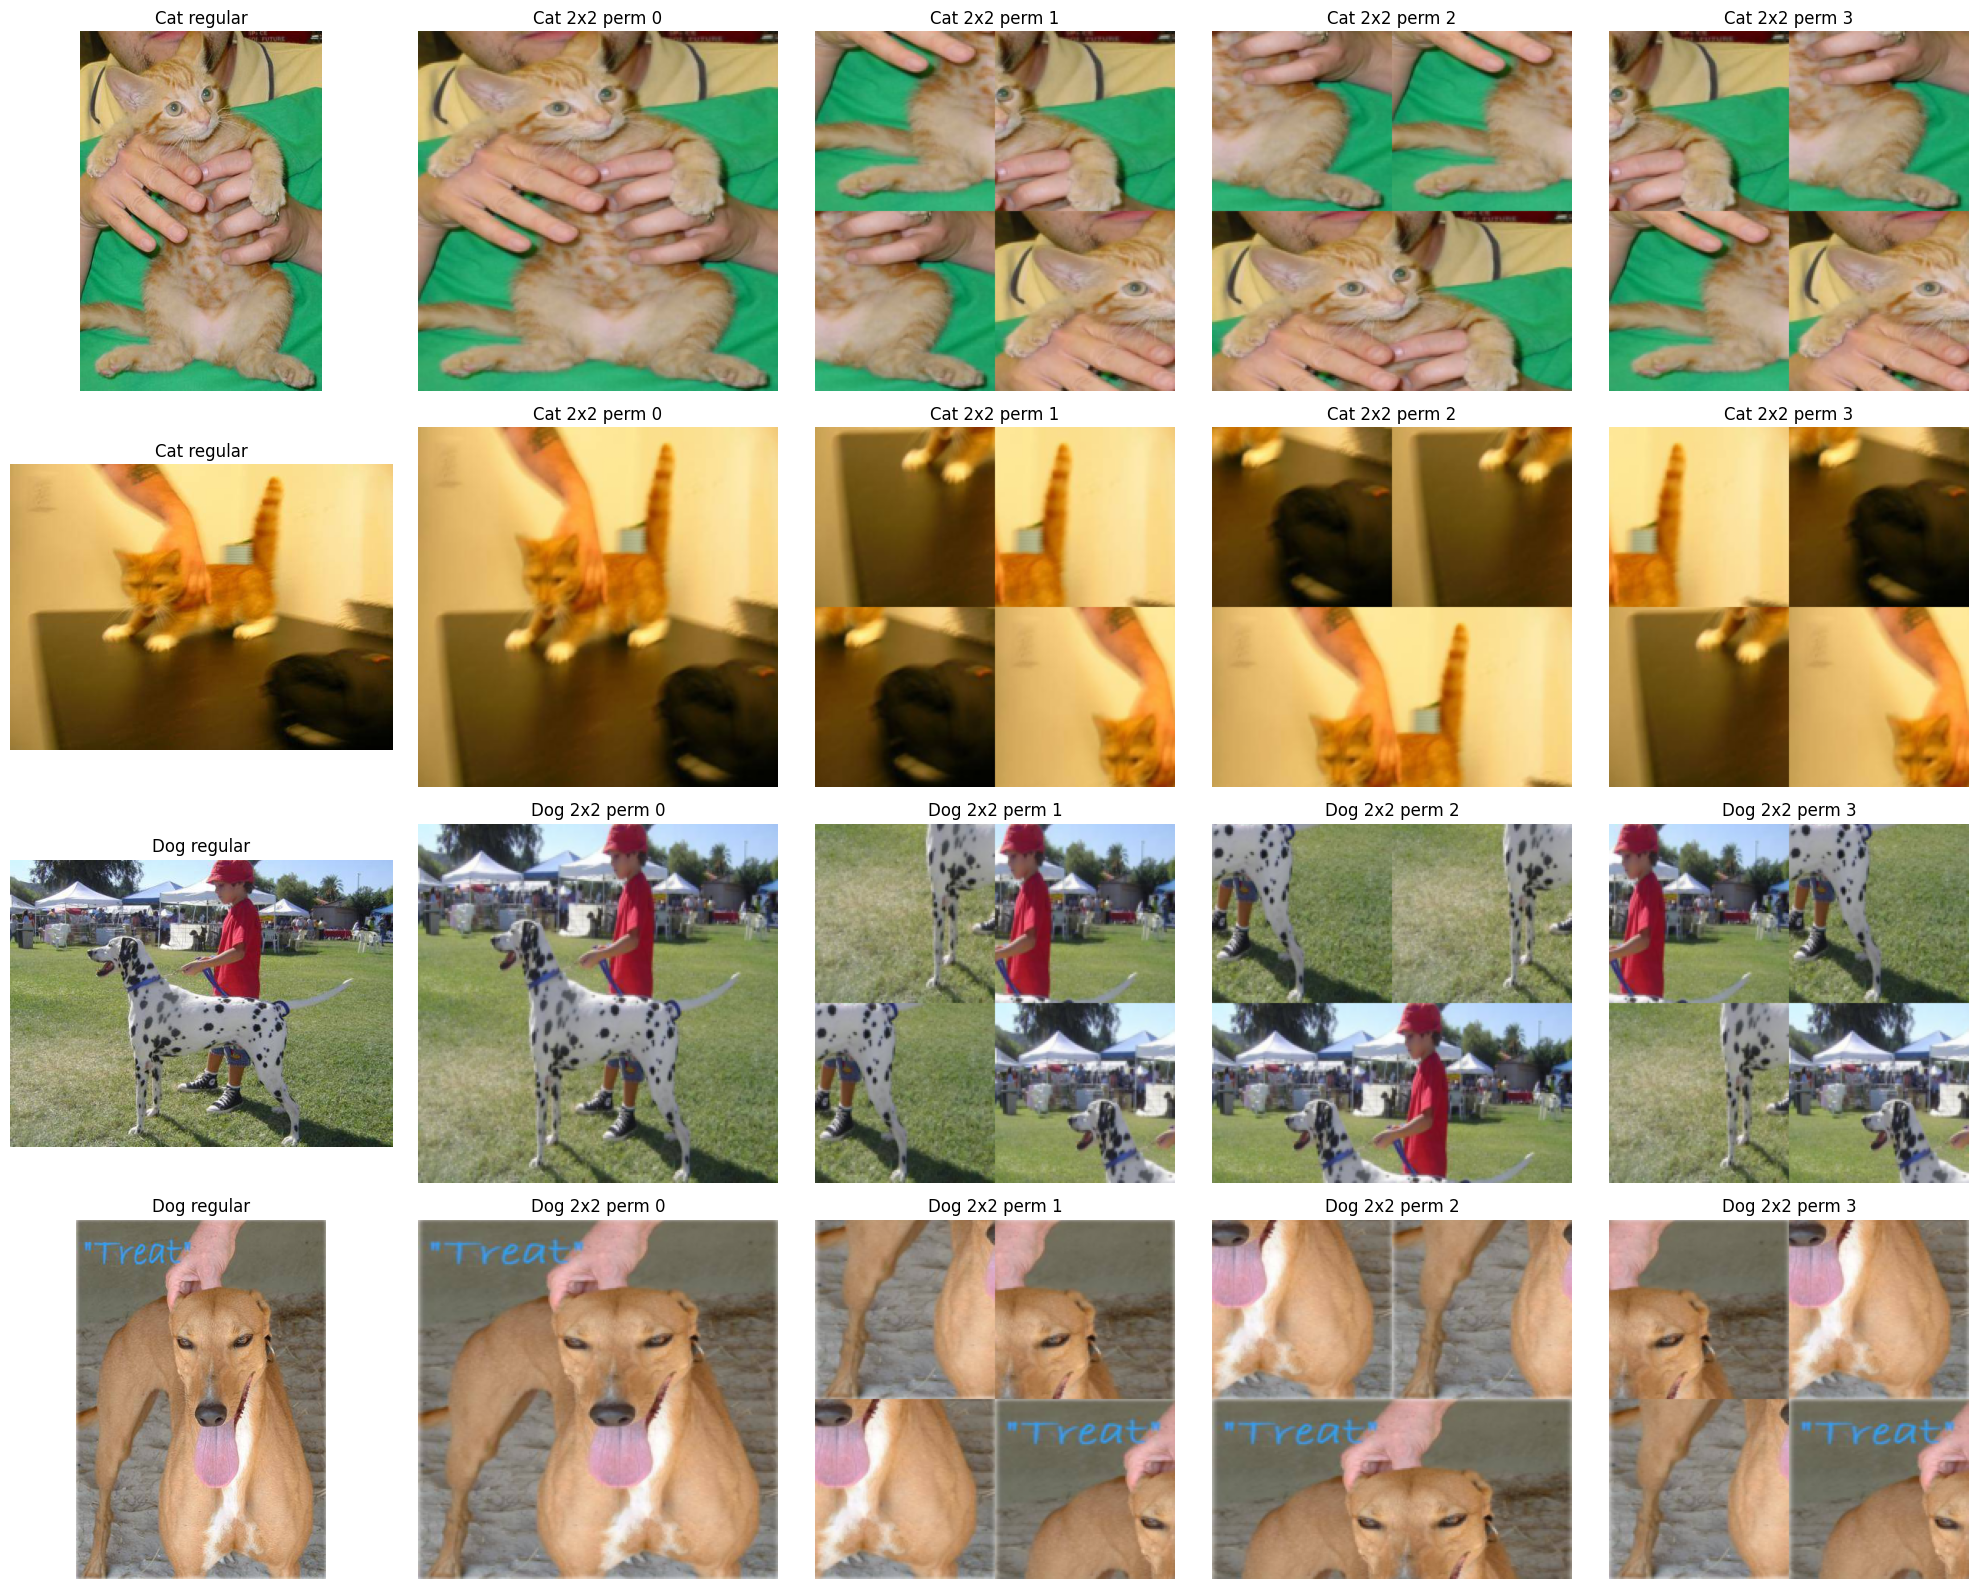

In [11]:
# Build and save permutation records
permutation_records = build_permutation_records(
    grid_sizes=configs.grid_sizes,
    num_permutations=configs.num_permutations,
    seed=configs.seed,
    include_identity=True,
)
permutation_rows = [record.__dict__ | {'permutation': json.dumps(record.permutation)} for record in permutation_records]
save_csv(data=permutation_rows, path=output_paths['permutations'])
print(f"Saved {len(permutation_records)} permutation records")

if configs.plot_samples:
    import matplotlib.pyplot as plt

    plot_permutation_samples(
        samples=train_samples,
        permutation_records=permutation_records,
        image_size=configs.image_size,
    )
    plt.show()


In [12]:
# Setup reproducibility and load data
seed = configs.seed
seed_everything(seed=seed, deterministic=configs.deterministic)
# Data already loaded above
print(f"Loaded {len(train_samples)} train, {len(validation_samples)} val samples")

Loaded 26 train, 6 val samples


In [13]:
# Prepare shared result accumulation across model runs
all_rows = []
run_id = configs.config_name

### Train ResNet-50
ResNet-50 is a convolutional residual network from the ResNet family. It uses skip connections to train a deeper CNN reliably and serves as a strong convolutional baseline.

In [14]:
model_name = "resnet50"
device = get_device(config=configs)
rows = collect_model_permutation_results(
    config=configs,
    model_name=model_name,
    run_id=run_id,
    train_samples=train_samples,
    validation_samples=validation_samples,
    permutation_records=permutation_records,
    seed=seed,
    device=device,
)
all_rows.extend(rows)
save_rows(rows=all_rows, output_path=output_paths['raw_results'])
print(f"Completed training ResNet-50 with {len(rows)} runs")


[1/5] Running permutation grid=1x1, permutation_id=0, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'resnet50' on the current permutation...
Building training components for model 'resnet50'...
Finished building training components for model 'resnet50'.
Training model 'resnet50' for 5 epoch(s)...


Epoch:   0%|          | 0/5 [00:00<?, ?epoch/s]/Users/royrubin/Documents/GitHub/MLDS_Final_Project/src/training/engine.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp and device.type == "cuda")
/Users/royrubin/Documents/GitHub/MLDS_Final_Project/src/training/engine.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp and device.type == "cuda"):


Finished training model 'resnet50'. Metrics: {'train_loss': 0.737569469671983, 'train_accuracy': 0.5769230769230769, 'val_loss': 0.92560213804245, 'val_accuracy': 0.5, 'best_val_accuracy': 0.5}
Done training model 'resnet50' on permutation_id=0.

[2/5] Running permutation grid=2x2, permutation_id=0, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'resnet50' on the current permutation...
Building training components for model 'resnet50'...
Finished building training components for model 'resnet50'.
Training model 'resnet50' for 5 epoch(s)...


Finished training model 'resnet50'. Metrics: {'train_loss': 0.5677923147494977, 'train_accuracy': 0.6538461538461539, 'val_loss': 0.8247788548469543, 'val_accuracy': 0.5, 'best_val_accuracy': 0.5}
Done training model 'resnet50' on permutation_id=0.

[3/5] Running permutation grid=2x2, permutation_id=1, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'resnet50' on the current permutation...
Building training components for model 'resnet50'...
Finished building training components for model 'resnet50'.
Training model 'resnet50' for 5 epoch(s)...


Finished training model 'resnet50'. Metrics: {'train_loss': 0.5482850533265334, 'train_accuracy': 0.6153846153846154, 'val_loss': 1.0551447868347168, 'val_accuracy': 0.5, 'best_val_accuracy': 0.5}
Done training model 'resnet50' on permutation_id=1.

[4/5] Running permutation grid=2x2, permutation_id=2, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'resnet50' on the current permutation...
Building training components for model 'resnet50'...
Finished building training components for model 'resnet50'.
Training model 'resnet50' for 5 epoch(s)...


Finished training model 'resnet50'. Metrics: {'train_loss': 0.6781803828019363, 'train_accuracy': 0.6153846153846154, 'val_loss': 1.0421724319458008, 'val_accuracy': 0.5, 'best_val_accuracy': 0.5}
Done training model 'resnet50' on permutation_id=2.

[5/5] Running permutation grid=2x2, permutation_id=3, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'resnet50' on the current permutation...
Building training components for model 'resnet50'...
Finished building training components for model 'resnet50'.
Training model 'resnet50' for 5 epoch(s)...


Finished training model 'resnet50'. Metrics: {'train_loss': 0.5462434016741239, 'train_accuracy': 0.7692307692307693, 'val_loss': 0.7371327877044678, 'val_accuracy': 0.5, 'best_val_accuracy': 0.5}
Done training model 'resnet50' on permutation_id=3.
Completed training ResNet-50 with 5 runs


### Train DeiT-Small
DeiT-Small comes from the data-efficient vision transformer family. It represents images as patch tokens and uses self-attention in a compact ViT-style architecture.

In [15]:
model_name = "deit_small"
rows = collect_model_permutation_results(
    config=configs,
    model_name=model_name,
    run_id=run_id,
    train_samples=train_samples,
    validation_samples=validation_samples,
    permutation_records=permutation_records,
    seed=seed,
    device=device,
)
all_rows.extend(rows)
save_rows(rows=all_rows, output_path=output_paths['raw_results'])
print(f"Completed training DeiT-Small with {len(rows)} runs")


[1/5] Running permutation grid=1x1, permutation_id=0, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'deit_small' on the current permutation...
Building training components for model 'deit_small'...
Finished building training components for model 'deit_small'.
Training model 'deit_small' for 5 epoch(s)...


Finished training model 'deit_small'. Metrics: {'train_loss': 0.7304274210563073, 'train_accuracy': 0.5, 'val_loss': 0.7339253425598145, 'val_accuracy': 0.5, 'best_val_accuracy': 0.6666666666666666}
Done training model 'deit_small' on permutation_id=0.

[2/5] Running permutation grid=2x2, permutation_id=0, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'deit_small' on the current permutation...
Building training components for model 'deit_small'...
Finished building training components for model 'deit_small'.
Training model 'deit_small' for 5 epoch(s)...


Finished training model 'deit_small'. Metrics: {'train_loss': 0.7174760470023522, 'train_accuracy': 0.5, 'val_loss': 0.7040624022483826, 'val_accuracy': 0.5, 'best_val_accuracy': 0.6666666666666666}
Done training model 'deit_small' on permutation_id=0.

[3/5] Running permutation grid=2x2, permutation_id=1, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'deit_small' on the current permutation...
Building training components for model 'deit_small'...
Finished building training components for model 'deit_small'.
Training model 'deit_small' for 5 epoch(s)...


Finished training model 'deit_small'. Metrics: {'train_loss': 0.7302019412700946, 'train_accuracy': 0.5384615384615384, 'val_loss': 0.7722862362861633, 'val_accuracy': 0.5, 'best_val_accuracy': 0.6666666666666666}
Done training model 'deit_small' on permutation_id=1.

[4/5] Running permutation grid=2x2, permutation_id=2, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'deit_small' on the current permutation...
Building training components for model 'deit_small'...
Finished building training components for model 'deit_small'.
Training model 'deit_small' for 5 epoch(s)...


Finished training model 'deit_small'. Metrics: {'train_loss': 0.6374623133586004, 'train_accuracy': 0.5, 'val_loss': 0.8685317635536194, 'val_accuracy': 0.3333333333333333, 'best_val_accuracy': 0.5}
Done training model 'deit_small' on permutation_id=2.

[5/5] Running permutation grid=2x2, permutation_id=3, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'deit_small' on the current permutation...
Building training components for model 'deit_small'...
Finished building training components for model 'deit_small'.
Training model 'deit_small' for 5 epoch(s)...


Finished training model 'deit_small'. Metrics: {'train_loss': 0.6290457936433645, 'train_accuracy': 0.6153846153846154, 'val_loss': 0.8784799575805664, 'val_accuracy': 0.3333333333333333, 'best_val_accuracy': 0.6666666666666666}
Done training model 'deit_small' on permutation_id=3.
Completed training DeiT-Small with 5 runs


### Train MLP-Mixer
MLP-Mixer is an all-MLP vision architecture. It alternates token-mixing and channel-mixing MLP layers, using neither convolution nor self-attention.

In [16]:
model_name = "mlp_mixer"
rows = collect_model_permutation_results(
    config=configs,
    model_name=model_name,
    run_id=run_id,
    train_samples=train_samples,
    validation_samples=validation_samples,
    permutation_records=permutation_records,
    seed=seed,
    device=device,
)
all_rows.extend(rows)
save_rows(rows=all_rows, output_path=output_paths['raw_results'])
print(f"Completed training MLP-Mixer with {len(rows)} runs")


[1/5] Running permutation grid=1x1, permutation_id=0, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'mlp_mixer' on the current permutation...
Building training components for model 'mlp_mixer'...
Finished building training components for model 'mlp_mixer'.
Training model 'mlp_mixer' for 5 epoch(s)...


Finished training model 'mlp_mixer'. Metrics: {'train_loss': 0.6346939985568707, 'train_accuracy': 0.8076923076923077, 'val_loss': 0.6865642666816711, 'val_accuracy': 0.6666666666666666, 'best_val_accuracy': 0.6666666666666666}
Done training model 'mlp_mixer' on permutation_id=0.

[2/5] Running permutation grid=2x2, permutation_id=0, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'mlp_mixer' on the current permutation...
Building training components for model 'mlp_mixer'...
Finished building training components for model 'mlp_mixer'.
Training model 'mlp_mixer' for 5 epoch(s)...


Finished training model 'mlp_mixer'. Metrics: {'train_loss': 0.5985382245137141, 'train_accuracy': 0.8461538461538461, 'val_loss': 0.6788143515586853, 'val_accuracy': 0.6666666666666666, 'best_val_accuracy': 0.6666666666666666}
Done training model 'mlp_mixer' on permutation_id=0.

[3/5] Running permutation grid=2x2, permutation_id=1, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'mlp_mixer' on the current permutation...
Building training components for model 'mlp_mixer'...
Finished building training components for model 'mlp_mixer'.
Training model 'mlp_mixer' for 5 epoch(s)...


Finished training model 'mlp_mixer'. Metrics: {'train_loss': 0.567787032860976, 'train_accuracy': 0.8846153846153846, 'val_loss': 0.638810396194458, 'val_accuracy': 0.6666666666666666, 'best_val_accuracy': 0.6666666666666666}
Done training model 'mlp_mixer' on permutation_id=1.

[4/5] Running permutation grid=2x2, permutation_id=2, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'mlp_mixer' on the current permutation...
Building training components for model 'mlp_mixer'...
Finished building training components for model 'mlp_mixer'.
Training model 'mlp_mixer' for 5 epoch(s)...


Finished training model 'mlp_mixer'. Metrics: {'train_loss': 0.6662055116433364, 'train_accuracy': 0.7692307692307693, 'val_loss': 0.6797969937324524, 'val_accuracy': 0.5, 'best_val_accuracy': 0.6666666666666666}
Done training model 'mlp_mixer' on permutation_id=2.

[5/5] Running permutation grid=2x2, permutation_id=3, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'mlp_mixer' on the current permutation...
Building training components for model 'mlp_mixer'...
Finished building training components for model 'mlp_mixer'.
Training model 'mlp_mixer' for 5 epoch(s)...


Finished training model 'mlp_mixer'. Metrics: {'train_loss': 0.5460764834514031, 'train_accuracy': 0.8461538461538461, 'val_loss': 0.7372586131095886, 'val_accuracy': 0.3333333333333333, 'best_val_accuracy': 0.5}
Done training model 'mlp_mixer' on permutation_id=3.
Completed training MLP-Mixer with 5 runs


In [17]:
# Aggregate results and plot
raw_results = pd.read_csv(filepath_or_buffer=output_paths['raw_results'])
aggregated_results = save_aggregated_accuracy(
    raw_results=raw_results,
    group_columns=['model_name', 'grid_size', 'num_tiles'],
    output_path=output_paths['aggregated_results'],
)
plot_accuracy_vs_tiles(aggregated=aggregated_results, output_path=output_paths['accuracy_plot'])
aggregated_results

,model_name,grid_size,num_tiles,mean_val_accuracy,std_val_accuracy,mean_best_val_accuracy,std_best_val_accuracy,n_runs
0,deit_small,1,1,0.500000,NaN,0.666667,NaN,1
1,deit_small,2,4,0.416667,0.096225,0.625000,0.083333,4
2,mlp_mixer,1,1,0.666667,NaN,0.666667,NaN,1
3,mlp_mixer,2,4,0.541667,0.159571,0.625000,0.083333,4
4,resnet50,1,1,0.500000,NaN,0.500000,NaN,1
5,resnet50,2,4,0.500000,0.000000,0.500000,0.000000,4


### Experiments - Results Table
Reload the saved aggregated CSV so the report is reproducible from disk. Each row averages all permutation scores for the same model and tile count.


In [18]:
saved_results = {
    'raw': pd.read_csv(filepath_or_buffer=output_paths['raw_results']),
    'aggregated': pd.read_csv(filepath_or_buffer=output_paths['aggregated_results']),
}
display(saved_results['aggregated'])

,model_name,grid_size,num_tiles,mean_val_accuracy,std_val_accuracy,mean_best_val_accuracy,std_best_val_accuracy,n_runs
0,deit_small,1,1,0.500000,NaN,0.666667,NaN,1
1,deit_small,2,4,0.416667,0.096225,0.625000,0.083333,4
2,mlp_mixer,1,1,0.666667,NaN,0.666667,NaN,1
3,mlp_mixer,2,4,0.541667,0.159571,0.625000,0.083333,4
4,resnet50,1,1,0.500000,NaN,0.500000,NaN,1
5,resnet50,2,4,0.500000,0.000000,0.500000,0.000000,4


### Experiments - Accuracy Plot
Display the saved accuracy-vs-number-of-tiles plot.


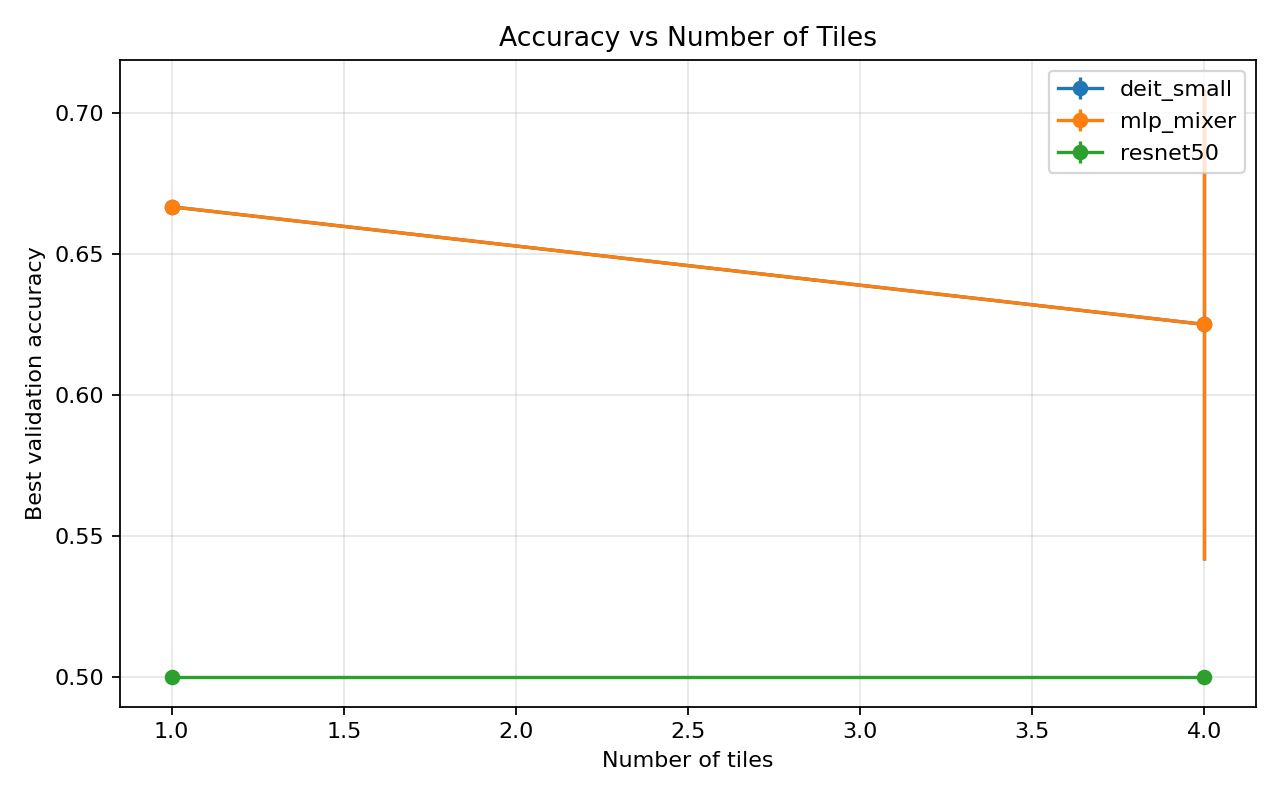

In [19]:
figure_path = output_paths['accuracy_plot']
if Path(figure_path).exists():
    display(Image(filename=figure_path))
else:
    print(f'Plot not found yet: {figure_path}')
